# 07 · Anatomía del error de aristas

El notebook 05 mostró **qué** falla (subdibujado: ~9 aristas generadas contra ~12.4 del
ground truth). Este mide **por qué**, descomponiendo cada arista perdida en su causa y
midiendo el fenómeno estructural que domina: **la brecha de bidireccionalidad**.

Es la sección que convierte un número bajo en un diagnóstico, y la que fundamenta los
experimentos del notebook 08.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")
import networkx as nx
from rich.console import Console

import scripts.core.graph_builder as _gb
from scripts.core.graph_builder import create_graph_from_cloudscape_json

_gb.console = Console(quiet=True)      # silencia "Graph created: ..." por video

GT_DIR = Path("../data/cloudscape_gt")
ABL    = Path("../reports/ablation")
RUN_DIR = ABL / "2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4"   # produccion, panel 30
pd.set_option("display.width", 200)

RUN = json.loads((RUN_DIR / "run.json").read_text(encoding="utf-8"))
RES = {r["video_id"]: r for r in RUN["results"] if r["status"] == "success"}

GEN = {v: create_graph_from_cloudscape_json(r["analysis"], video_id=v) for v, r in RES.items()}
GT  = {v: nx.read_graphml(GT_DIR / f"{v}.graphml") for v in RES}

print(f"corrida: {RUN_DIR.name}")
print(f"videos : {len(RES)}")
print(f"aristas generadas: {sum(g.number_of_edges() for g in GEN.values())} · "
      f"en el GT: {sum(g.number_of_edges() for g in GT.values())}")

corrida: 2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4
videos : 30
aristas generadas: 271 · en el GT: 361


## 1 · Por qué se pierde cada arista

Para cada arista del ground truth que el modelo **no** produjo, hay exactamente tres
situaciones posibles, y distinguirlas cambia por completo qué habría que arreglar:

| causa | qué significa | ¿se puede arreglar en Stage 2? |
|---|---|---|
| **falta un nodo** | el servicio ni siquiera está en el grafo | no — es un problema aguas arriba |
| **falta el retorno** | el modelo puso `a→b` pero el GT también tiene `b→a` | quizá — es una regla de generación |
| **sin conexión** | los dos nodos están, pero nunca se conectaron | quizá — es inferencia de topología |

,aristas,%
causa,,
falta la arista de RETORNO,81,44.8
falta un nodo,61,33.7
"ambos nodos presentes, sin conexion",39,21.5



aristas del GT     : 361
aristas perdidas   : 181 (50.1%)


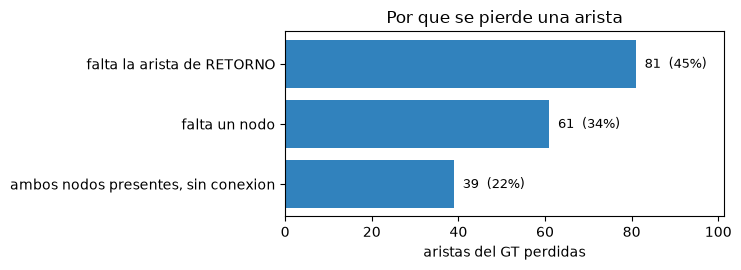

In [2]:
def pares(G) -> Counter:
    return Counter((G.nodes[u].get("service", "?"), G.nodes[v].get("service", "?"))
                   for u, v in G.edges())

def clasificar(g, t):
    gc, tc = pares(g), pares(t)
    svcs = {g.nodes[n].get("service", "") for n in g}
    out = []
    for (a, b), k in (tc - gc).items():
        if a not in svcs or b not in svcs:
            causa = "falta un nodo"
        elif gc.get((b, a), 0) > 0:
            causa = "falta la arista de RETORNO"
        else:
            causa = "ambos nodos presentes, sin conexion"
        out.append({"causa": causa, "arista": f"{a} -> {b}", "n": k,
                    "extremo_ausente": None if causa != "falta un nodo"
                                       else (a if a not in svcs else b)})
    return out

perdidas = [d for v in RES for d in clasificar(GEN[v], GT[v])]
PF = pd.DataFrame(perdidas)

res = PF.groupby("causa")["n"].sum().sort_values(ascending=False).to_frame("aristas")
res["%"] = (100 * res["aristas"] / res["aristas"].sum()).round(1)
display(res)

tot_gt = sum(g.number_of_edges() for g in GT.values())
print(f"\naristas del GT     : {tot_gt}")
print(f"aristas perdidas   : {res['aristas'].sum()} ({100 * res['aristas'].sum() / tot_gt:.1f}%)")

fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.barh(res.index[::-1], res["aristas"][::-1], color="#3182bd")
for i, v in enumerate(res["aristas"][::-1]):
    ax.text(v + 2, i, f"{v}  ({res['%'][::-1].iloc[i]:.0f}%)", va="center", fontsize=9)
ax.set_xlabel("aristas del GT perdidas"); ax.set_xlim(0, res["aristas"].max() * 1.25)
ax.set_title("Por que se pierde una arista"); plt.tight_layout(); plt.show()

## 2 · Qué nodos ausentes cuestan más aristas

La segunda causa se puede atacar de raíz si unos pocos tipos de servicio concentran el
daño. Se cuenta cuántas aristas arrastra cada servicio ausente.

In [3]:
falt = PF[PF.causa == "falta un nodo"]
top = falt.groupby("extremo_ausente")["n"].sum().sort_values(ascending=False)
display(top.head(12).to_frame("aristas que arrastra"))

es_actor = top.index.to_series().apply(
    lambda s: str(s).startswith("User") or str(s).startswith("ThirdParty"))
print(f"\naristas perdidas por nodo ausente         : {int(top.sum())}")
print(f"  ... cuyo extremo ausente es User*/ThirdParty: {int(top[es_actor.values].sum())} "
      f"({100 * top[es_actor.values].sum() / top.sum():.0f}%)")
print("\nLos actores humanos y sistemas externos son los nodos que mas aristas cuestan\n"
      "cuando faltan. El prompt de produccion los PODA explicitamente (regla 5).")

,aristas que arrastra
extremo_ausente,
UserConsumerWeb,22
ThirdParty,10
UserCompanyDataStream,6
UserCompanyAgent,5
MSK,3
UserCompanyDeveloper,3
UserConsumerAPI,2
UserConsumerMobile,2
SNS,1



aristas perdidas por nodo ausente         : 61
  ... cuyo extremo ausente es User*/ThirdParty: 53 (87%)

Los actores humanos y sistemas externos son los nodos que mas aristas cuestan
cuando faltan. El prompt de produccion los PODA explicitamente (regla 5).


Ese dato es el que motivó la variante V8 del notebook 08: el prompt ofrece un vocabulario
`User and Client Actors` en el encabezado y después ordena eliminar actores humanos. **Se
contradice a sí mismo**, y esa contradicción tiene un costo medible en aristas.

## 3 · La brecha de bidireccionalidad

La causa dominante merece medirse como fenómeno propio: ¿qué proporción de las relaciones
está dibujada en **los dos sentidos**?

Se mide **por servicio**, que es la convención del evaluador (`ID-agnostic`), y por lo
tanto la única cifra comparable con el Edge F1.

% medio de pares bidireccionales
  ground truth : 52.6%
  produccion   : 15.1%
  brecha       : 37.5 puntos


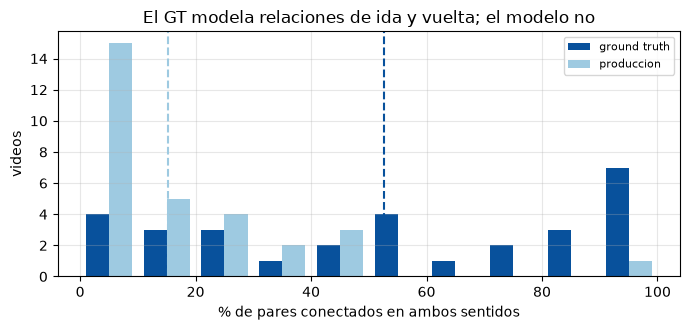

In [4]:
def pct_bidireccional(G) -> float:
    """% de pares de servicio distintos conectados en AMBOS sentidos."""
    p = pares(G)
    und = {tuple(sorted((a, b))) for a, b in p if a != b}
    if not und:
        return np.nan
    bi = sum(1 for a, b in und if p.get((a, b), 0) and p.get((b, a), 0))
    return 100 * bi / len(und)

bi = pd.DataFrame({
    "video": list(RES),
    "GT": [pct_bidireccional(GT[v]) for v in RES],
    "produccion": [pct_bidireccional(GEN[v]) for v in RES],
}).set_index("video")

print(f"% medio de pares bidireccionales")
print(f"  ground truth : {bi['GT'].mean():.1f}%")
print(f"  produccion   : {bi['produccion'].mean():.1f}%")
print(f"  brecha       : {bi['GT'].mean() - bi['produccion'].mean():.1f} puntos")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist([bi["GT"].dropna(), bi["produccion"].dropna()], bins=10,
        label=["ground truth", "produccion"], color=["#08519c", "#9ecae1"])
ax.axvline(bi["GT"].mean(), color="#08519c", ls="--")
ax.axvline(bi["produccion"].mean(), color="#9ecae1", ls="--")
ax.set_xlabel("% de pares conectados en ambos sentidos"); ax.set_ylabel("videos")
ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title("El GT modela relaciones de ida y vuelta; el modelo no")
plt.tight_layout(); plt.show()

> **Nota sobre cifras previas.** El `ara/` reporta 46.7 % / 12.4 % para esta brecha. Acá se
> recalcula desde los archivos vigentes con la definición explícita de arriba (pares de
> servicio distintos, self-loops excluidos). Si difiere, **vale la de este notebook**, que
> es la que se puede auditar celda por celda.

## 4 · ¿Cuánto valdría acertar la dirección?

Cota superior del beneficio: se colapsa a pares **no dirigidos** en los dos lados y se
vuelve a puntuar. Es lo máximo que se ganaría si la dirección fuera gratis — no un
resultado alcanzable, sino un techo.

In [5]:
def f1(inter, gen, gt):
    p = inter / gen if gen else 0.0
    r = inter / gt if gt else 0.0
    return 2 * p * r / (p + r) if p + r else 0.0

def edge_f1_dirigido(g, t):
    gc, tc = pares(g), pares(t)
    return f1(sum((gc & tc).values()), sum(gc.values()), sum(tc.values()))

def edge_f1_no_dirigido(g, t):
    """Funde a<->b a nivel de PAR DE NODOS antes de mapear a servicios (ver notebook 03)."""
    def col(G):
        und = {tuple(sorted((u, v))) for u, v in G.edges()}
        return Counter(tuple(sorted((G.nodes[u].get("service", "?"),
                                     G.nodes[v].get("service", "?")))) for u, v in und)
    gc, tc = col(g), col(t)
    return f1(sum((gc & tc).values()), sum(gc.values()), sum(tc.values()))

dirg = np.mean([edge_f1_dirigido(GEN[v], GT[v]) for v in RES]) * 100
nodir = np.mean([edge_f1_no_dirigido(GEN[v], GT[v]) for v in RES]) * 100
print(f"Edge F1 dirigido (estricto) : {dirg:.2f}")
print(f"Edge F1 no dirigido (techo) : {nodir:.2f}")
print(f"la direccion cuesta          : {nodir - dirg:.2f} puntos")

OUT = Path("../reports/anatomia_aristas.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/07_anatomia_error_aristas.ipynb",
    "corrida": RUN_DIR.name,
    "aristas_gt": int(tot_gt), "aristas_perdidas": int(res["aristas"].sum()),
    "causas": res["aristas"].to_dict(),
    "aristas_por_nodo_ausente_top": top.head(12).to_dict(),
    "bidireccionalidad_pct": {"gt": round(float(bi["GT"].mean()), 1),
                              "produccion": round(float(bi["produccion"].mean()), 1)},
    "edge_f1_dirigido": round(float(dirg), 2),
    "edge_f1_no_dirigido": round(float(nodir), 2),
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nescrito -> {OUT}")

Edge F1 dirigido (estricto) : 57.87
Edge F1 no dirigido (techo) : 69.58
la direccion cuesta          : 11.72 puntos

escrito -> ../reports/anatomia_aristas.json


## Para el paper

1. **La mitad de las aristas del ground truth no se genera**, y la causa dominante es la
   arista de **retorno** ausente.
2. La segunda causa —**nodo ausente**— está concentrada en actores `User*` y `ThirdParty`,
   que el prompt de producción poda por una regla que **se contradice** con su propio
   vocabulario.
3. La **brecha de bidireccionalidad** es un fenómeno estructural: el ground truth modela
   relaciones de ida y vuelta y el modelo emite casi siempre una sola dirección.
4. Acertar la dirección valdría varios puntos, pero es un **techo**, no una mejora
   disponible: el notebook 08 muestra que intentar cobrarlo no funciona.